
There are 116 rows, and 10 columns.

=======DATASET_INFO======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB
None

=======SUMMARY_STATS======
              Age         BMI     Glucose     Insulin        HOMA      Leptin  \
count  116.000000  116.000000  116.000000  116.000000  116.000000  116.000000   
mean    57.301724   27.582111   97.793103   10

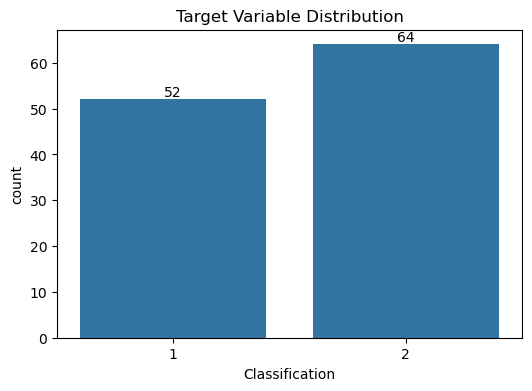

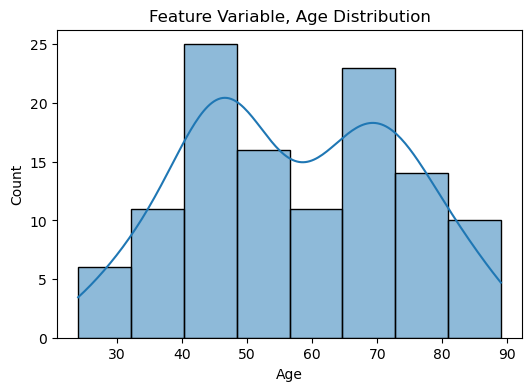

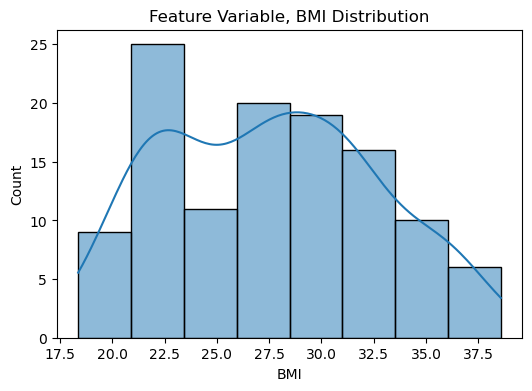

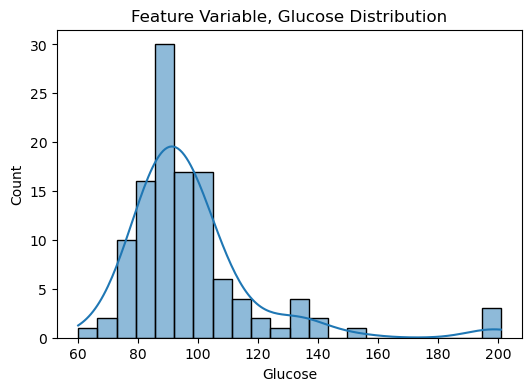

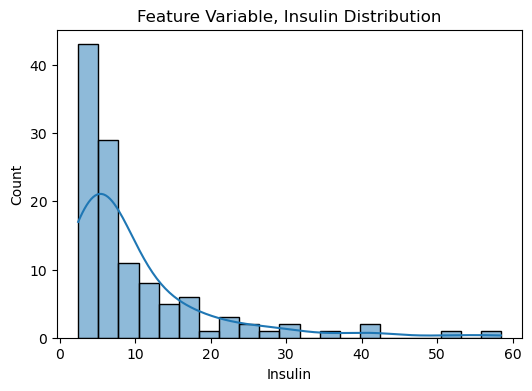

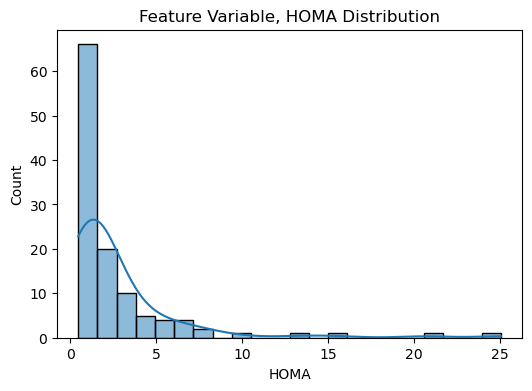

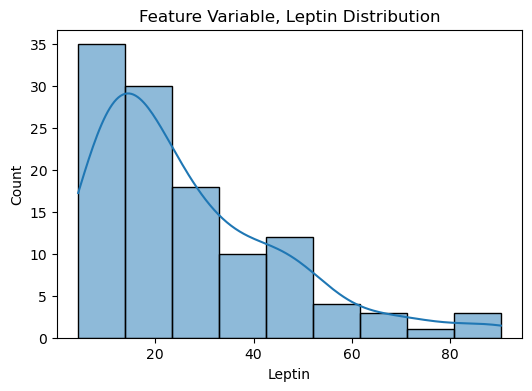

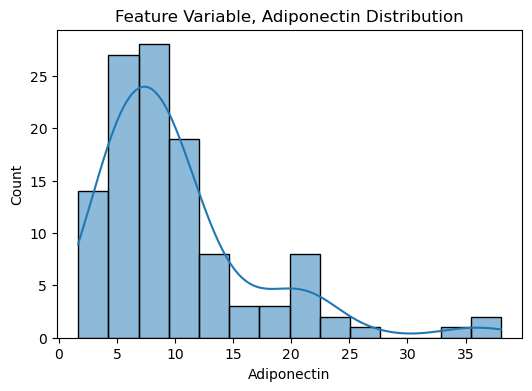

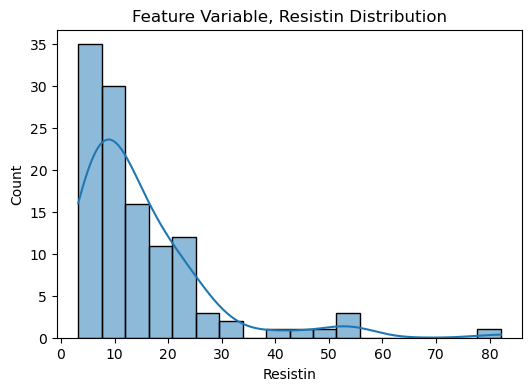

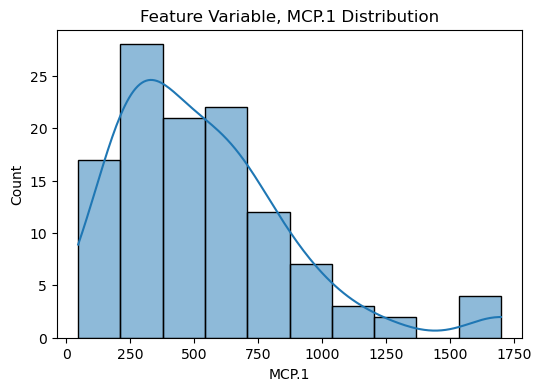

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn import datasets  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


path = r"C:\Users\dylan\OneDrive\Documents\GRAD_SCHOOL\DAAN_682\HOMEWORK_8"
target = "Classification"
os.chdir(path)
breastcancer = pd.read_csv("breastcancer.csv")

#1.) Data exploration
print(f"\nThere are {breastcancer.shape[0]} rows, and {breastcancer.shape[1]} columns.")
print("\n=======DATASET_INFO======")
print(breastcancer.info())
print("\n=======SUMMARY_STATS======")
print(breastcancer.describe())
breastcancer_corr = breastcancer.corr()
print(f"\n Here is the correlation martrix: {breastcancer_corr}")
print("\n===== MISSING VALUES =====")
print(f"{breastcancer.isnull().sum()}")
print("\n===== DUPLICATE ROWS =====")
print(f"The total number of duplicate rows is: {breastcancer.duplicated().sum()}")

# Here is the plot for the target variable (classification)
plt.figure(figsize=(6,4))
counter = sns.countplot(x=breastcancer[target])
for container in counter.containers:
    counter.bar_label(container)
plt.title("Target Variable Distribution")
plt.show()

# Here is the visualization of the feature variables
for col in breastcancer.columns:
    if(col != target):
        plt.figure(figsize=(6,4))
        sns.histplot(breastcancer[col], kde=True)
        plt.title(f"Feature Variable, {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()


In [2]:
#2.) 
features = breastcancer.drop(columns=[target])
targets = breastcancer[target]

features_train, features_test, targets_train, targets_test = train_test_split(
    features, targets, test_size=0.30, random_state=42
)

print(f"\nTraining set size: {features_train.shape}")
print(f"Test set size: {features_test.shape}")

log_model = LogisticRegression(max_iter=1000)
log_model.fit(features_train,targets_train)
targets_pred_log = log_model.predict(features_test)


print("\n MODEL PERFORMANCE for logistic Regression")
print(f"Accuracy: {accuracy_score(targets_test, targets_pred_log)}")

print("\n CONFUSION MATRIX FOR LOGISTIC REGRESSION")
print(confusion_matrix(targets_test, targets_pred_log))

print("\n CLASSIFICATION REPORT FOR LOGISTIC REGRESSION")
print(classification_report(targets_test, targets_pred_log))


Training set size: (81, 9)
Test set size: (35, 9)

 MODEL PERFORMANCE for logistic Regression
Accuracy: 0.7428571428571429

 CONFUSION MATRIX FOR LOGISTIC REGRESSION
[[14  3]
 [ 6 12]]

 CLASSIFICATION REPORT FOR LOGISTIC REGRESSION
              precision    recall  f1-score   support

           1       0.70      0.82      0.76        17
           2       0.80      0.67      0.73        18

    accuracy                           0.74        35
   macro avg       0.75      0.75      0.74        35
weighted avg       0.75      0.74      0.74        35



In [3]:
#3.) 
nb_model = GaussianNB()

nb_model.fit(features_train, targets_train)

targets_pred_nb = nb_model.predict(features_test)


print("\n NAIVE BAYES MODEL PERFORMANCE")
print(f"Accuracy: {accuracy_score(targets_test, targets_pred_nb)}")

print("\n CONFUSION MATRIX FOR BAYES NAIVE")
print(confusion_matrix(targets_test, targets_pred_nb))

print("\n CLASSIFICATION REPORT BAYES NAIVE")
print(classification_report(targets_test, targets_pred_nb))


 NAIVE BAYES MODEL PERFORMANCE
Accuracy: 0.6571428571428571

 CONFUSION MATRIX FOR BAYES NAIVE
[[15  2]
 [10  8]]

 CLASSIFICATION REPORT BAYES NAIVE
              precision    recall  f1-score   support

           1       0.60      0.88      0.71        17
           2       0.80      0.44      0.57        18

    accuracy                           0.66        35
   macro avg       0.70      0.66      0.64        35
weighted avg       0.70      0.66      0.64        35




 DECISION TREE MODEL PERFORMANCE
Accuracy: 0.7714285714285715

 CONFUSION MATRIX FOR DECISION TREE
[[12  5]
 [ 3 15]]

 CLASSIFICATION REPORT DECISION TREE
              precision    recall  f1-score   support

           1       0.80      0.71      0.75        17
           2       0.75      0.83      0.79        18

    accuracy                           0.77        35
   macro avg       0.78      0.77      0.77        35
weighted avg       0.77      0.77      0.77        35



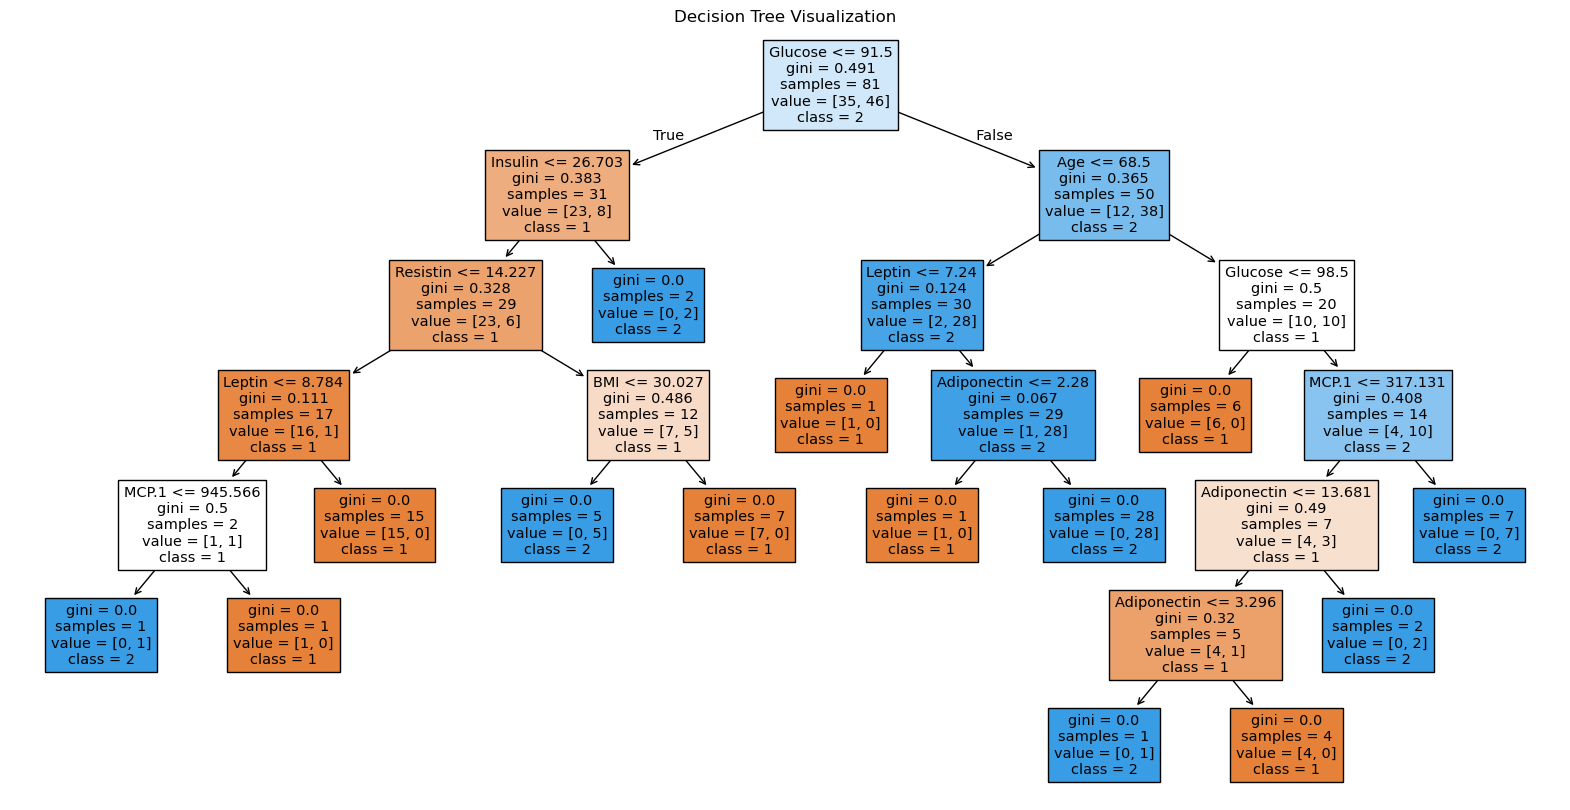

In [4]:
#4.) 
dt_model = DecisionTreeClassifier(random_state=9)
dt_model.fit(features_train, targets_train)
targets_pred_dt = dt_model.predict(features_test)

print("\n DECISION TREE MODEL PERFORMANCE")
print(f"Accuracy: {accuracy_score(targets_test, targets_pred_dt)}")

print("\n CONFUSION MATRIX FOR DECISION TREE")
print(confusion_matrix(targets_test, targets_pred_dt))

print("\n CLASSIFICATION REPORT DECISION TREE")
print(classification_report(targets_test, targets_pred_dt))

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=features.columns,
    class_names=[str(c) for c in dt_model.classes_],
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()


In [5]:
#5.) 
nn_model = MLPClassifier(hidden_layer_sizes=(10,10),
                         activation = 'relu',
                         solver='adam',
                         max_iter=1000,
                         random_state=42)
nn_model.fit(features_train, targets_train)
targets_pred_nn = nn_model.predict(features_test)

print("\n NEURAL NETWORK MODEL PERFORMANCE")
print(f"Accuracy: {accuracy_score(targets_test, targets_pred_nn)}")

print("\n CONFUSION MATRIX for NEURAL NETWORK")
print(confusion_matrix(targets_test, targets_pred_nn))

print("\n CLASSIFICATION REPORT FORE NEURAL NETWORK")
print(classification_report(targets_test, targets_pred_nn))



 NEURAL NETWORK MODEL PERFORMANCE
Accuracy: 0.8

 CONFUSION MATRIX for NEURAL NETWORK
[[14  3]
 [ 4 14]]

 CLASSIFICATION REPORT FORE NEURAL NETWORK
              precision    recall  f1-score   support

           1       0.78      0.82      0.80        17
           2       0.82      0.78      0.80        18

    accuracy                           0.80        35
   macro avg       0.80      0.80      0.80        35
weighted avg       0.80      0.80      0.80        35



In [6]:
print("\n MODEL PERFORMANCE for logistic Regression")
print(f"Accuracy: {accuracy_score(targets_test, targets_pred_log)}")
print("\n NAIVE BAYES MODEL PERFORMANCE")
print(f"Accuracy: {accuracy_score(targets_test, targets_pred_nb)}")
print("\n DECISION TREE MODEL PERFORMANCE")
print(f"Accuracy: {accuracy_score(targets_test, targets_pred_dt)}")
print("\n NEURAL NETWORK MODEL PERFORMANCE")
print(f"Accuracy: {accuracy_score(targets_test, targets_pred_nn)}")

print("\n CLASSIFICATION REPORT FOR LOGISTIC REGRESSION")
print(classification_report(targets_test, targets_pred_log))
print("\n CLASSIFICATION REPORT BAYES NAIVE")
print(classification_report(targets_test, targets_pred_nb))
print("\n CLASSIFICATION REPORT DECISION TREE")
print(classification_report(targets_test, targets_pred_dt))
print("\n CLASSIFICATION REPORT FORE NEURAL NETWORK")
print(classification_report(targets_test, targets_pred_nn))

print("Based on the accuracy, and on the classification reports, the neural network model produce the best results.\n")
print("This model has the highest accuracy at: 0.8. It also produces the highest F1 score which is a balance between precision and recall. ")
print("Based on the top node in the decision tree, we can see the most important variable is glucose")


 MODEL PERFORMANCE for logistic Regression
Accuracy: 0.7428571428571429

 NAIVE BAYES MODEL PERFORMANCE
Accuracy: 0.6571428571428571

 DECISION TREE MODEL PERFORMANCE
Accuracy: 0.7714285714285715

 NEURAL NETWORK MODEL PERFORMANCE
Accuracy: 0.8

 CLASSIFICATION REPORT FOR LOGISTIC REGRESSION
              precision    recall  f1-score   support

           1       0.70      0.82      0.76        17
           2       0.80      0.67      0.73        18

    accuracy                           0.74        35
   macro avg       0.75      0.75      0.74        35
weighted avg       0.75      0.74      0.74        35


 CLASSIFICATION REPORT BAYES NAIVE
              precision    recall  f1-score   support

           1       0.60      0.88      0.71        17
           2       0.80      0.44      0.57        18

    accuracy                           0.66        35
   macro avg       0.70      0.66      0.64        35
weighted avg       0.70      0.66      0.64        35


 CLASSIFICATION